<a href="https://colab.research.google.com/github/TANUSHRI-BHISE/deep-learning/blob/main/cats_vs_dogs1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [2]:
!kaggle datasets download -d bhavikjikadara/dog-and-cat-classification-dataset

Dataset URL: https://www.kaggle.com/datasets/bhavikjikadara/dog-and-cat-classification-dataset
License(s): apache-2.0
100% 775M/775M [00:05<00:00, 156MB/s]



In [4]:
import zipfile
zip_ref=zipfile.ZipFile('/content/dog-and-cat-classification-dataset.zip','r')
zip_ref.extractall('/content')
zip_ref.close()

In [30]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout

In [6]:
import os

base_dir = "/content/dataset"

train_cat = os.path.join(base_dir, "train/cat")
train_dog = os.path.join(base_dir, "train/dog")
test_cat = os.path.join(base_dir, "test/cat")
test_dog = os.path.join(base_dir, "test/dog")

for folder in [train_cat, train_dog, test_cat, test_dog]:
    os.makedirs(folder, exist_ok=True)

In [7]:
import shutil
import random

def split_data(source, train_dir, test_dir, split_size=0.8):
    files = os.listdir(source)
    random.shuffle(files)

    split_point = int(len(files) * split_size)

    train_files = files[:split_point]
    test_files = files[split_point:]

    for file in train_files:
        shutil.copy(os.path.join(source, file), train_dir)

    for file in test_files:
        shutil.copy(os.path.join(source, file), test_dir)

In [8]:
split_data("/content/PetImages/Cat", train_cat, test_cat)
split_data("/content/PetImages/Dog", train_dog, test_dog)

In [9]:
from PIL import Image

def clean_folder(folder):
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        try:
            Image.open(path)
        except:
            os.remove(path)

for folder in [train_cat, train_dog, test_cat, test_dog]:
    clean_folder(folder)

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


In [10]:
print("Train Cats:", len(os.listdir(train_cat)))
print("Train Dogs:", len(os.listdir(train_dog)))
print("Test Cats:", len(os.listdir(test_cat)))
print("Test Dogs:", len(os.listdir(test_dog)))

Train Cats: 9999
Train Dogs: 9999
Test Cats: 2500
Test Dogs: 2500


In [11]:
train_ds=keras.utils.image_dataset_from_directory(
    directory='/content/dataset/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)


Found 19998 files belonging to 2 classes.


In [12]:
val_ds=keras.utils.image_dataset_from_directory(
    directory='/content/dataset/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

Found 5000 files belonging to 2 classes.


In [13]:
# we have numpy array of image we need to normalize it

In [14]:
def process(image,label):
  image=tf.cast(image/255,tf.float32)
  return image,label
train_ds=train_ds.map(process)
val_ds=val_ds.map(process)

In [15]:
#create cnn model
model=Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',))
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,686,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,142,725 (42.51 MB)

 Trainable params: 3,714,241 (14.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,428,484 (28.34 MB)

In [23]:
train_ds = train_ds.apply(tf.data.experimental.ignore_errors())

In [24]:
val_ds = val_ds.apply(tf.data.experimental.ignore_errors())

In [25]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [26]:
history=model.fit(train_ds,epochs=10,validation_data=val_ds)

Epoch 1/10
    621/Unknown 41s 59ms/step - accuracy: 0.6425 - loss: 0.6259

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


621/621 ━━━━━━━━━━━━━━━━━━━━ 50s 73ms/step - accuracy: 0.6868 - loss: 0.5866 - val_accuracy: 0.7394 - val_loss: 0.5238
Epoch 2/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 82s 132ms/step - accuracy: 0.7778 - loss: 0.4652 - val_accuracy: 0.7715 - val_loss: 0.4937
Epoch 3/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 103s 69ms/step - accuracy: 0.8360 - loss: 0.3677 - val_accuracy: 0.7749 - val_loss: 0.5537
Epoch 4/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 45s 73ms/step - accuracy: 0.8968 - loss: 0.2472 - val_accuracy: 0.7569 - val_loss: 0.7361
Epoch 5/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.9449 - loss: 0.1368 - val_accuracy: 0.7641 - val_loss: 0.9828
Epoch 6/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.9655 - loss: 0.0967 - val_accuracy: 0.7480 - val_loss: 1.1257
Epoch 7/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - accuracy: 0.9781 - loss: 0.0617 - val_accuracy: 0.7480 - val_loss: 1.1884
Epoch 8/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - accuracy: 0.9839 - loss: 0.0481 - val_accur

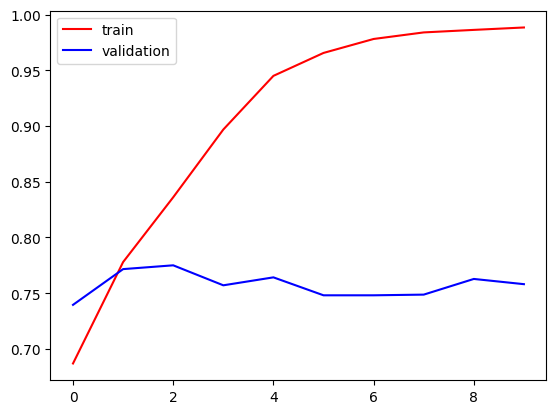

In [27]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

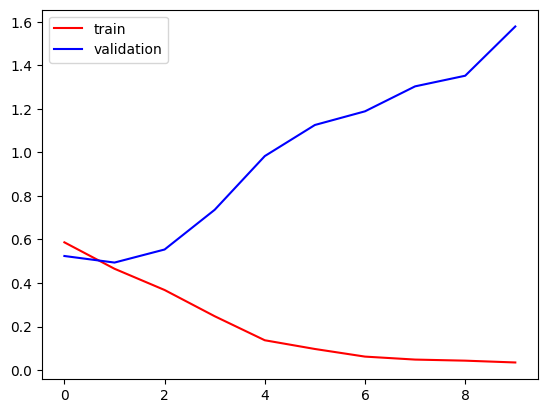

In [28]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [34]:
#adding dropout and batcnormalization
model=Sequential()
model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2),strides=2,padding='valid'))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(64,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 125, 125, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 125, 125, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 60, 60, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 60, 60, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 28800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │     3,686,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,714,625 (14.17 MB)

 Trainable params: 3,714,433 (14.17 MB)

 Non-trainable params: 192 (768.00 B)

In [36]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [37]:
history=model.fit(train_ds,epochs=10,validation_data=val_ds)

Epoch 1/10
    621/Unknown 47s 67ms/step - accuracy: 0.5926 - loss: 0.9418

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


621/621 ━━━━━━━━━━━━━━━━━━━━ 55s 78ms/step - accuracy: 0.6227 - loss: 0.7499 - val_accuracy: 0.5983 - val_loss: 0.6767
Epoch 2/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 44s 70ms/step - accuracy: 0.7149 - loss: 0.5530 - val_accuracy: 0.7516 - val_loss: 0.5093
Epoch 3/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 46s 74ms/step - accuracy: 0.7749 - loss: 0.4679 - val_accuracy: 0.7810 - val_loss: 0.4676
Epoch 4/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 50s 80ms/step - accuracy: 0.8137 - loss: 0.4027 - val_accuracy: 0.7932 - val_loss: 0.4554
Epoch 5/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 42s 67ms/step - accuracy: 0.8479 - loss: 0.3388 - val_accuracy: 0.7614 - val_loss: 0.5974
Epoch 6/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - accuracy: 0.8809 - loss: 0.2731 - val_accuracy: 0.7951 - val_loss: 0.4816
Epoch 7/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 43s 70ms/step - accuracy: 0.9145 - loss: 0.2054 - val_accuracy: 0.7743 - val_loss: 0.6234
Epoch 8/10
621/621 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - accuracy: 0.9370 - loss: 0.1500 - val_accurac

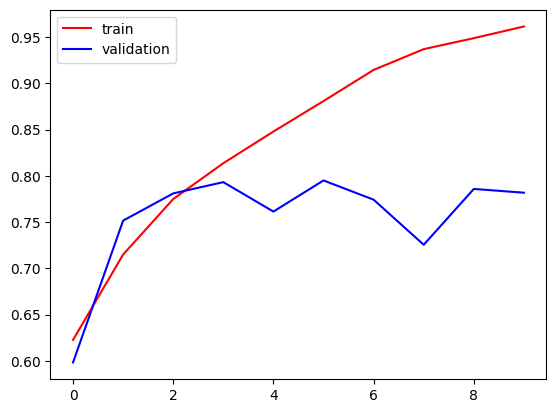

In [38]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color='red',label='train')
plt.plot(history.history['val_accuracy'],color='blue',label='validation')
plt.legend()
plt.show()

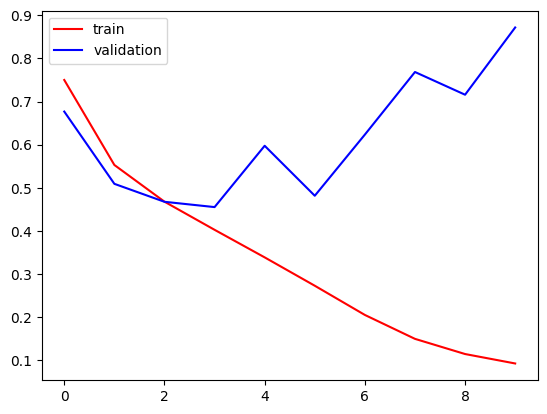

In [40]:
plt.plot(history.history['loss'],color='red',label='train')
plt.plot(history.history['val_loss'],color='blue',label='validation')
plt.legend()
plt.show()

In [39]:
import cv2

In [58]:
test_img=cv2.imread('/content/cat_test.jpg')

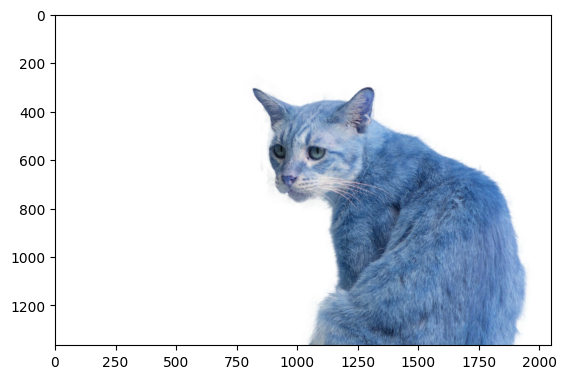

In [59]:
plt.imshow(test_img)

In [60]:
test_img.shape

(1365, 2048, 3)

In [64]:
from tensorflow.keras.preprocessing import image
import numpy as np

# STEP 1: Load and resize image
img = image.load_img('/content/cat_test.jpg', target_size=(256, 256))

# STEP 2: Convert to array
test_img = image.img_to_array(img)

# STEP 3: Normalize (VERY IMPORTANT if you trained like this)
test_img = test_img / 255.0

# STEP 4: Add batch dimension
test_input = np.expand_dims(test_img, axis=0)

print(test_input.shape)   # should be (1,256,256,3)

(1, 256, 256, 3)


In [65]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[0.99927807]], dtype=float32)

In [66]:
from tensorflow.keras.preprocessing import image
import numpy as np

# STEP 1: Load and resize image
img = image.load_img('/content/dog_test.jpg', target_size=(256, 256))

# STEP 2: Convert to array
test_img = image.img_to_array(img)

# STEP 3: Normalize (VERY IMPORTANT if you trained like this)
test_img = test_img / 255.0

# STEP 4: Add batch dimension
test_input = np.expand_dims(test_img, axis=0)

print(test_input.shape)   # should be (1,256,256,3)

(1, 256, 256, 3)


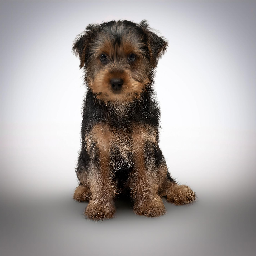

In [68]:
img

In [70]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


array([[0.999835]], dtype=float32)

In [71]:
from tensorflow.keras.preprocessing import image
import numpy as np

# STEP 1: Load and resize image
img = image.load_img('/content/dogs_test.jpg', target_size=(256, 256))

# STEP 2: Convert to array
test_img = image.img_to_array(img)

# STEP 3: Normalize (VERY IMPORTANT if you trained like this)
test_img = test_img / 255.0

# STEP 4: Add batch dimension
test_input = np.expand_dims(test_img, axis=0)

print(test_input.shape)   # should be (1,256,256,3)

(1, 256, 256, 3)


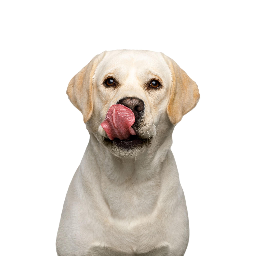

In [72]:
img

In [73]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


array([[1.]], dtype=float32)